In [1]:
from pathlib import Path
import backtest

EXPERIMENT    = "healthcare_ic"       # matches results/final_<NAME>_reg.ubj
SECTORS       = ["healthcare"]        # None = all sectors
TOP_QUANTILE  = 0.2
BOT_QUANTILE  = 0                   # 0 = long-only
REBALANCE     = "staggered"               # "fixed" | "staggered"
MAX_HOLD_DAYS = 548                   # staggered cap only
MIN_STOCKS    = 3
OUTPUT_DIR    = Path("backtest_results")

In [2]:
df = backtest.load_dataset(SECTORS)
START, END = backtest.infer_test_window(df)
print(f"Test window: {START}  →  {END}")

Dataset: 22,163 rows | 837 tickers
Test window: 2023-05-15  →  2025-05-15


Loaded  final_healthcare_ic_reg.ubj  (100 feats | train IC=0.3406 ICIR=4.9889)
Dataset: 22,163 rows | 837 tickers
Features available for inference: 100

Backtest  2023Q2 → 2025Q2  (9 Qs)  mode=staggered  long=20%  short=0%



Quarters:  11%|█         | 1/9 [00:00<00:06,  1.28it/s]

  2023Q2  n=603→121  long=+12.38%  comb=+12.38%  SPY≈+9.44%  alpha=+2.94%  IC=+0.174


Quarters:  22%|██▏       | 2/9 [00:01<00:04,  1.68it/s]

  2023Q3  n=625→125  long=-11.22%  comb=-11.22%  SPY≈-2.56%  alpha=-8.66%  IC=-0.318


...

  2024Q3  n=757→152  long=+13.44%  comb=+13.44%  SPY≈+10.21%  alpha=+3.23%  IC=-0.070


Quarters:  78%|███████▊  | 7/9 [00:03<00:00,  2.26it/s]

  2024Q4  n=793→158  [1 skipped]  long=+8.89%  comb=+8.89%  SPY≈-0.44%  alpha=+9.33%  IC=+0.078


Quarters: 100%|██████████| 9/9 [00:03<00:00,  2.32it/s]


  2025Q1  n=812→  6  [157 skipped]  long=-3.04%  comb=-3.04%  SPY≈-4.95%  alpha=+1.91%  IC=+0.771
  2025Q2: no prices resolved — skip

─── Backtest Summary ────────────────────────────────────────────────
  Mode                  : staggered
  Quarters with results : 8 / 9
  Mean quarterly IC     : +0.0984  (std=0.3199)

  Long leg
    Mean qtrly return   : +8.99%
    Annualised Sharpe   : 0.964
    Win rate            : 62.5%
    Max drawdown        : -11.22%

  Combined L/S
    Mean qtrly return   : +8.99%
    Annualised Sharpe   : 0.964
    Total return        : +81.72%
    Max drawdown        : -11.22%

  SPY benchmark (per-position avg window)
    Mean qtrly return   : +4.37%
    Annualised Sharpe   : 1.197
    Total return        : +38.41%
    Max drawdown        : -5.38%

  Mean position-level alpha : +4.63%
  Mean hold period (days)   : 95

Saved → backtest_results/backtest_healthcare_ic_staggered_quarterly.csv
Saved → backtest_results/backtest_healthcare_ic_staggered_trades.csv

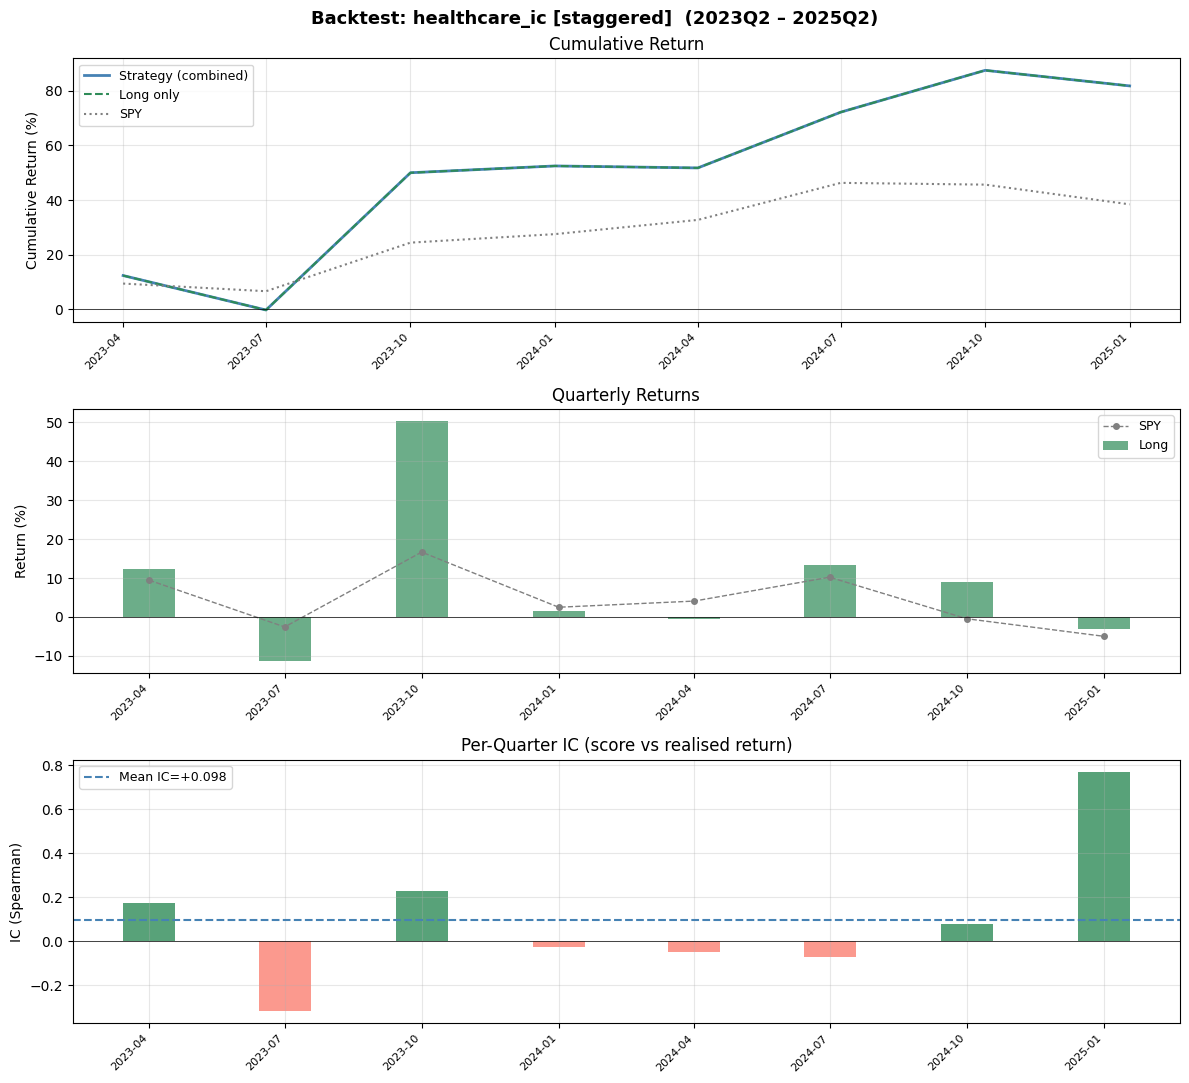

In [3]:
results = backtest.run_backtest(
    experiment_name = EXPERIMENT,
    sectors         = SECTORS,
    top_q           = TOP_QUANTILE,
    bot_q           = BOT_QUANTILE,
    start_date      = START,
    end_date        = END,
    rebalance_mode  = REBALANCE,
    max_hold_days   = MAX_HOLD_DAYS,
    min_stocks      = MIN_STOCKS,
    output_dir      = OUTPUT_DIR,
)